In [1]:
#imports:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np 
import read_spe as spe
import glob
import os
import numba

Reading in all files


#### if using Erin's folder setup (all power for each wavelength in one folder) using the following 2 cells to read in files

In [4]:
# p = r"D:\Karina Data 2.16.26\Empty"
# undoped_nm_dict = {}
# undoped_nm_settings_dict = {}
# for root, dirs, files in os.walk(p):
#     wavelength = os.path.basename(root)
#     power_dict = {}
#     power_dict_settings = {}
#     for file in files:
#         fp = os.path.join(root, file)
#         if ".txt" in file:      
#             if "SETTINGS" in os.path.basename(fp):
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#             else:
#                 name = os.path.basename(fp)
#                 power = name.split("_")[2]
#                 power = power.split("mW")[0]
#                 power_dict[power] = pd.read_csv(fp, sep="\t")
#         else:
#             continue  
#     undoped_nm_dict[wavelength] = power_dict
#     undoped_nm_settings_dict[wavelength] = power_dict_settings

In [5]:
# p = r"D:\Karina Data 2.16.26\Doped"
# doped_nm_dict = {}
# doped_nm_settings_dict = {}
#     for root, dirs, files in os.walk(p):
#         wavelength = os.path.basename(root)
#         power_dict = {}
#         power_dict_settings = {}
#         for file in files:
#             fp = os.path.join(root, file)
#             if ".txt" in file:      
#                 if "SETTINGS" in os.path.basename(fp):
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power=  power.split("mW")[0]
#                     power_dict_settings[power] = pd.read_csv(fp, sep=":",header=None)
#                 else:
#                     name = os.path.basename(fp)
#                     power = name.split("_")[2]
#                     power = power.split("mW")[0]
#                     power_dict[power] = pd.read_csv(fp, sep="\t")
#             else:
#                 continue
#     doped_nm_dict[wavelength] = power_dict
#     doped_nm_settings_dict[wavelength] = power_dict_settings

#### if using Karina's file setup (folder for each power inside each wavelength folder) use following 2 cells to read in files)

In [7]:
undoped_path = r"D:\Karina Data 2.16.26\Empty"
#set up dictionaries
undoped_nm_dict = {}
undoped_nm_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(undoped_path):
    print(wavelength_folder)
    wavelength_path = os.path.join(undoped_path, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:  
                #read in as settings file
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    #read in as power file
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue

    undoped_nm_dict[wavelength] = power_dict
    undoped_nm_settings_dict[wavelength] = power_settings_dict

LPS 730 nm
LPS 743 nm
LPS 757 nm
LPS 711 nm
LPS 721 nm


In [8]:
#repeat for doped
doped_path = r"D:\Karina Data 2.16.26\Doped"
doped_nm_dict = {}
doped_nm_settings_dict = {}
for wavelength_folder in os.listdir(doped_path):
    wavelength_path = os.path.join(doped_path, wavelength_folder)
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        power = power.replace(" mW","")
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".txt" in file:
                if "SETTINGS" in file:
                    power_settings_dict[power] = pd.read_csv(fp, sep=":", header=None)
                else:
                    power_dict[power] = pd.read_csv(fp, sep="\t")
            else:
                continue
    doped_nm_dict[wavelength] = power_dict
    doped_nm_settings_dict[wavelength] = power_settings_dict

In [9]:
print(undoped_nm_dict['757'].keys())

dict_keys(['0', '0.1', '0.3', '1', '3', '5'])


In [10]:
#needs to be same length as doped - if this is not an issue, comment out this cell
del undoped_nm_dict['721']['5']

In [11]:
print(undoped_nm_settings_dict)

{'730': {'0':                         0             1
0           VI Start Time  3.854893e+09
1        CCD Exposure (s)  1.000000e-02
2     CCD Frames/Exposure  1.000000e+00
3   Power Meter Range (W)  1.451223e-02
4  PM Set Wavelength (nm)  7.600000e+02
5     PM Attenuation (dB)  0.000000e+00, '0.1':                         0             1
0           VI Start Time  3.854893e+09
1        CCD Exposure (s)  1.000000e-02
2     CCD Frames/Exposure  1.000000e+00
3   Power Meter Range (W)  1.451223e-02
4  PM Set Wavelength (nm)  7.600000e+02
5     PM Attenuation (dB)  0.000000e+00, '0.3':                         0             1
0           VI Start Time  3.854893e+09
1        CCD Exposure (s)  1.000000e-02
2     CCD Frames/Exposure  1.000000e+00
3   Power Meter Range (W)  1.451223e-02
4  PM Set Wavelength (nm)  7.600000e+02
5     PM Attenuation (dB)  0.000000e+00, '1':                         0             1
0           VI Start Time  3.854892e+09
1        CCD Exposure (s)  1.000000e-02
2   

In [12]:
#sorting to make sure powers are in order
undoped_nm_dict = {k: v for k, v in sorted(undoped_nm_dict.items(), key=lambda item: item[0])}
undoped_nm_settings_dict = {k: v for k, v in sorted(undoped_nm_settings_dict.items(), key=lambda item: item[0])}
doped_nm_dict = {k: v for k, v in sorted(doped_nm_dict.items(), key=lambda item: item[0])}
doped_nm_settings_dict = {k: v for k, v in sorted(doped_nm_settings_dict.items(), key=lambda item: item[0])}

In [13]:
print(doped_nm_settings_dict['711'])

{'0':                         0                        1
0           VI Start Time   3854125298.29489422000
1        CCD Exposure (s)                  0.01000
2     CCD Frames/Exposure                  1.00000
3   Power Meter Range (W)                         
4  PM Set Wavelength (nm)                         
5     PM Attenuation (dB)                         , '0.1':                         0                        1
0           VI Start Time   3854124979.89227915000
1        CCD Exposure (s)                  0.01000
2     CCD Frames/Exposure                  1.00000
3   Power Meter Range (W)                         
4  PM Set Wavelength (nm)                         
5     PM Attenuation (dB)                         , '0.3':                         0                        1
0           VI Start Time   3854124700.71737909000
1        CCD Exposure (s)                  0.01000
2     CCD Frames/Exposure                  1.00000
3   Power Meter Range (W)                         
4  PM Set

In [14]:
#convert dictionaries to lists for easier indexing
undoped_nm = []
for wavelength in undoped_nm_dict:
    power_dict = undoped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_nm.append(power_list)

undoped_settings_nm = []
for wavelength in undoped_nm_settings_dict:
    power_dict = undoped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_settings_nm.append(power_list)

doped_nm = []
for wavelength in doped_nm_dict:
    power_dict = doped_nm_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_nm.append(power_list)

doped_settings_nm = []
for wavelength in doped_nm_settings_dict:
    power_dict = doped_nm_settings_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_settings_nm.append(power_list)


In [15]:
#find average voltage for each undoped file, add them to a new list
#do the same with uncertainties
averageVoltageUndoped = []
for wavelength in undoped_nm: 
    wavelengthVoltageUndoped = []
    for power in wavelength:
        wavelengthVoltageUndoped.append(power.iloc[:,2].mean())
    averageVoltageUndoped.append(wavelengthVoltageUndoped)

In [16]:
#convert power meter range (W) to mW
pwr = 1.451223E-02 * 1000
#IF POWER RANGE IS NOT HTE SAME FOR EACH, MAKE SURE TO CHANGE PWR TO (doped_settings_nm[i][j].iloc[3,1])
#Erin's code says divide it by 2, not really sure why 
#power = voltage x power range / 2
#convert from V to mW
averagePowerUndoped = []
uncertaintyPowerUndoped = []
for i in range(len(undoped_nm)):
    wavelengthPowerUndoped = []
    wavelengthPowerUncertaintyUndoped = []
    for j in range(len(undoped_nm[i])):
        wavelengthPowerUndoped.append(averageVoltageUndoped[i][j] * pwr/2)
        wavelengthPowerUncertaintyUndoped.append((undoped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(103))
    averagePowerUndoped.append(wavelengthPowerUndoped)
    uncertaintyPowerUndoped.append(wavelengthPowerUncertaintyUndoped)

In [17]:
#find average counts per frame
averageCountsUndoped = []
uncertaintyCountsUndoped = []
cpsUndoped = []
uncertaintyCpsUndoped = []
for i in range(len(undoped_nm)):
    wavelengthCountsUndoped = []
    wavelengthCountsUndopedUncertainty = []
    for j in range(len(undoped_nm[i])):
        wavelengthCountsUndoped.append((undoped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsUndopedUncertainty.append((undoped_nm[i][j].iloc[:,4].std()))
    averageCountsUndoped.append(wavelengthCountsUndoped)
    uncertaintyCountsUndoped.append(wavelengthCountsUndopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(undoped_nm)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(undoped_nm[i])):
        wavelengthCps.append(averageCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])
        wavelengthUncertaintyCps.append((uncertaintyCountsUndoped[i][j]/undoped_settings_nm[0][0].iloc[1,1])/np.sqrt(103))
    cpsUndoped.append(wavelengthCps)
    uncertaintyCpsUndoped.append(wavelengthUncertaintyCps)

5


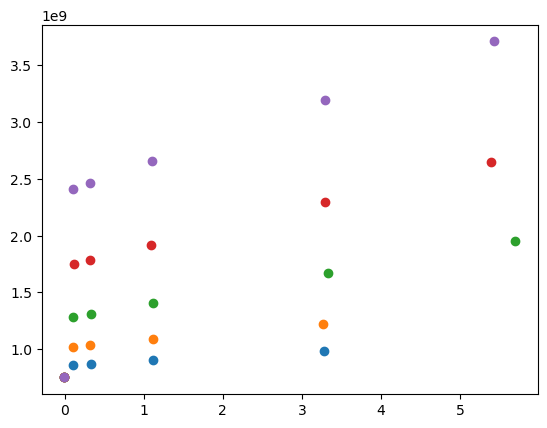

In [18]:

print(len(cpsUndoped))
for i in range(len(averagePowerUndoped)):
    plt.scatter(averagePowerUndoped[i],averageCountsUndoped[i])

In [19]:
#find average voltage for each doped file, add them to a new list
#do the same with uncertainties
averageVoltageDoped = []
for wavelength in doped_nm: 
    wavelengthVoltageDoped = []
    for power in wavelength:
        wavelengthVoltageDoped.append(power.iloc[:,2].mean())
    averageVoltageDoped.append(wavelengthVoltageDoped)

In [20]:
#convert power meter range (W) to mW
#convert from V to mW
averagePowerDoped = []
uncertaintyPowerDoped = []
for i in range(len(doped_nm)):
    wavelengthPowerDoped = []
    wavelengthPowerUncertaintyDoped = []
    for j in range(len(doped_nm[i])):
        wavelengthPowerDoped.append(averageVoltageDoped[i][j] * (pwr/2))
        wavelengthPowerUncertaintyDoped.append((doped_nm[i][j].iloc[:,2] * (pwr/2)).std() / np.sqrt(103))
    averagePowerDoped.append(wavelengthPowerDoped)
    uncertaintyPowerDoped.append(wavelengthPowerUncertaintyDoped)

In [21]:
float(doped_settings_nm[0][0].iloc[1,1])

0.01

In [22]:
#find average counts per frame
averageCountsDoped = []
uncertaintyCountsDoped = []
cpsDoped = []
uncertaintyCpsDoped = []
for i in range(len(doped_nm)):
    wavelengthCountsDoped = []
    wavelengthCountsDopedUncertainty = []
    for j in range(len(doped_nm[i])):
        wavelengthCountsDoped.append((doped_nm[i][j].iloc[:,4].mean()))
        wavelengthCountsDopedUncertainty.append((doped_nm[i][j].iloc[:,4].std()))
    averageCountsDoped.append(wavelengthCountsDoped)
    uncertaintyCountsDoped.append(wavelengthCountsDopedUncertainty)
#now counts per second, divide average by exposure time (from settings files)
for i in range(len(averageCountsDoped)):
    wavelengthCps = []
    wavelengthUncertaintyCps = []
    for j in range(len(averageCountsDoped[i])):
        wavelengthCps.append(averageCountsDoped[i][j]/float(doped_settings_nm[0][0].iloc[1,1]))
        wavelengthUncertaintyCps.append((uncertaintyCountsDoped[i][j]/float(doped_settings_nm[0][0].iloc[1,1]))/np.sqrt(103))
    cpsDoped.append(wavelengthCps)
    uncertaintyCpsDoped.append(wavelengthUncertaintyCps)

In [23]:
print(doped_settings_nm[0][0].iloc[1,1])

 0.01000


In [24]:
#now read in bias data (no film)
#THIS IS ERIN"S BIAS DATA!! DOES NOT WORK RIGHT NOW FOR KARINA"S NEW DATA!!
bias = pd.read_csv(
    r"C:\Users\summe\OneDrive\Desktop\FRIB\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342.txt"
    , sep="\t")
bias_settings = pd.read_csv(
    r"C:\Users\summe\OneDrive\Desktop\FRIB\2024-04-11 Bias for Laser Power Scans\Bias_LPS_2024-04-11-105342_SETTINGS.txt"
                            , header=None, sep=":")
#find average counts
bias_avg_counts = bias.iloc[:,4].mean()
#find counts per second
bias_cps = bias_avg_counts / (float(doped_settings_nm[0][0].iloc[1,1]))
#uncertainty
bias_uncertainty = np.std(bias.iloc[:,4]) / np.sqrt(103)

In [25]:
#subtract bias from doped and undoped datas
cpsDopedNoBias = []
for i in cpsDoped:
    cpsDopedNoBias.append(i-bias_cps)
cpsUndopedNoBias = []
for i in cpsUndoped:
    cpsUndopedNoBias.append(i-bias_cps)

In [26]:
#blah blah bias stuff
cpsUndopedArray = []
cpsUndopedNBArray = []
cpsDopedArray = []
cpsDopedNBArray = []
for i in range(len(cpsUndoped)):
    cpsUndopedArray.append(np.array(cpsUndoped[i]))
    cpsUndopedNBArray.append(np.array(cpsUndopedNoBias[i]))
for i in range(len(cpsDoped)):
    cpsDopedArray.append(np.array(cpsDoped[i]))
    cpsDopedNBArray.append(np.array(cpsDopedNoBias[i]))

Text(0.5, 1.0, 'Total Counts/s in Empty Kr Film')

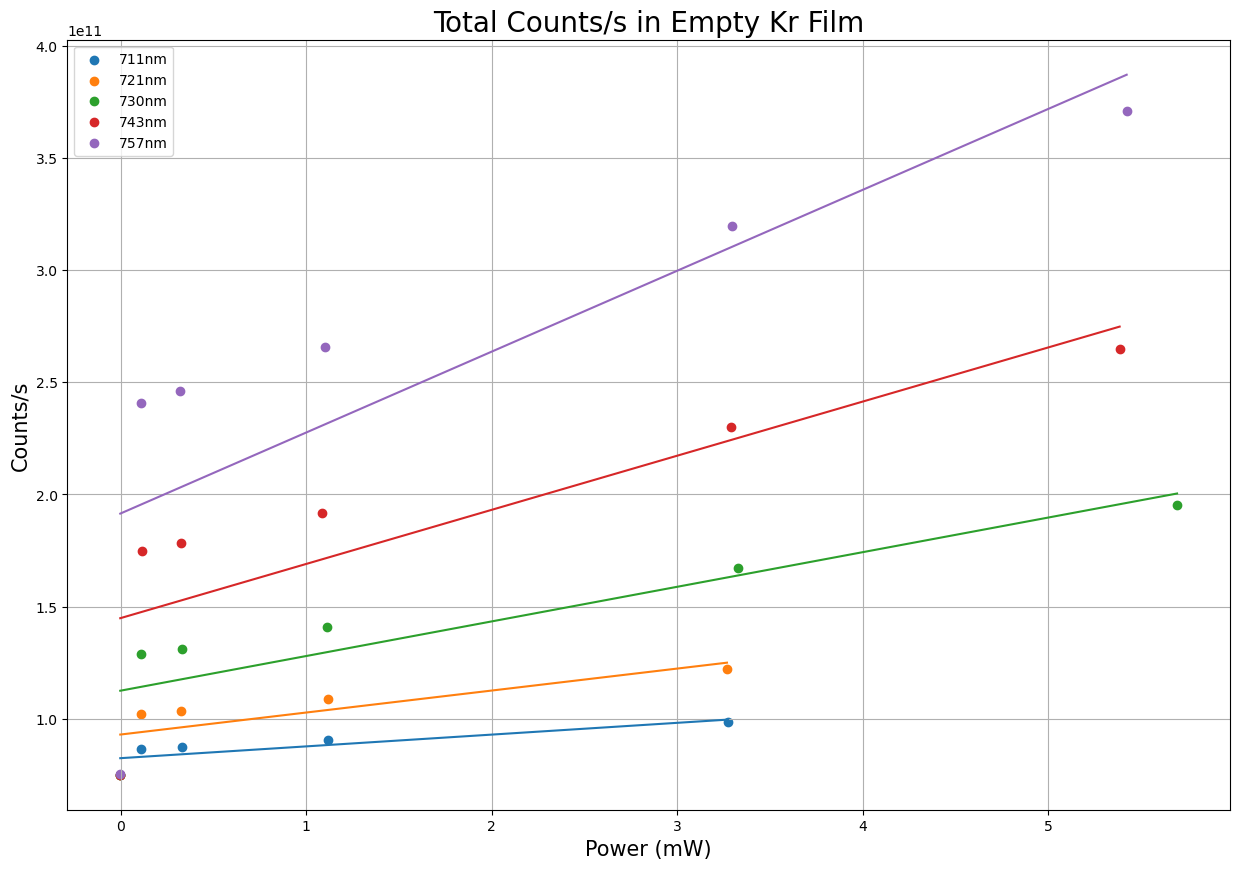

In [27]:
plt.figure(figsize=(15,10))
for i in range(len(cpsUndoped)):
    trend = np.polyfit(averagePowerUndoped[i], cpsUndoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cpsUndoped[i], label=list(undoped_nm_dict)[i]+"nm")
plt.legend()
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Empty Kr Film", fontsize=20)

Text(0.5, 1.0, 'Total Counts/s in Rb Doped Kr Film')

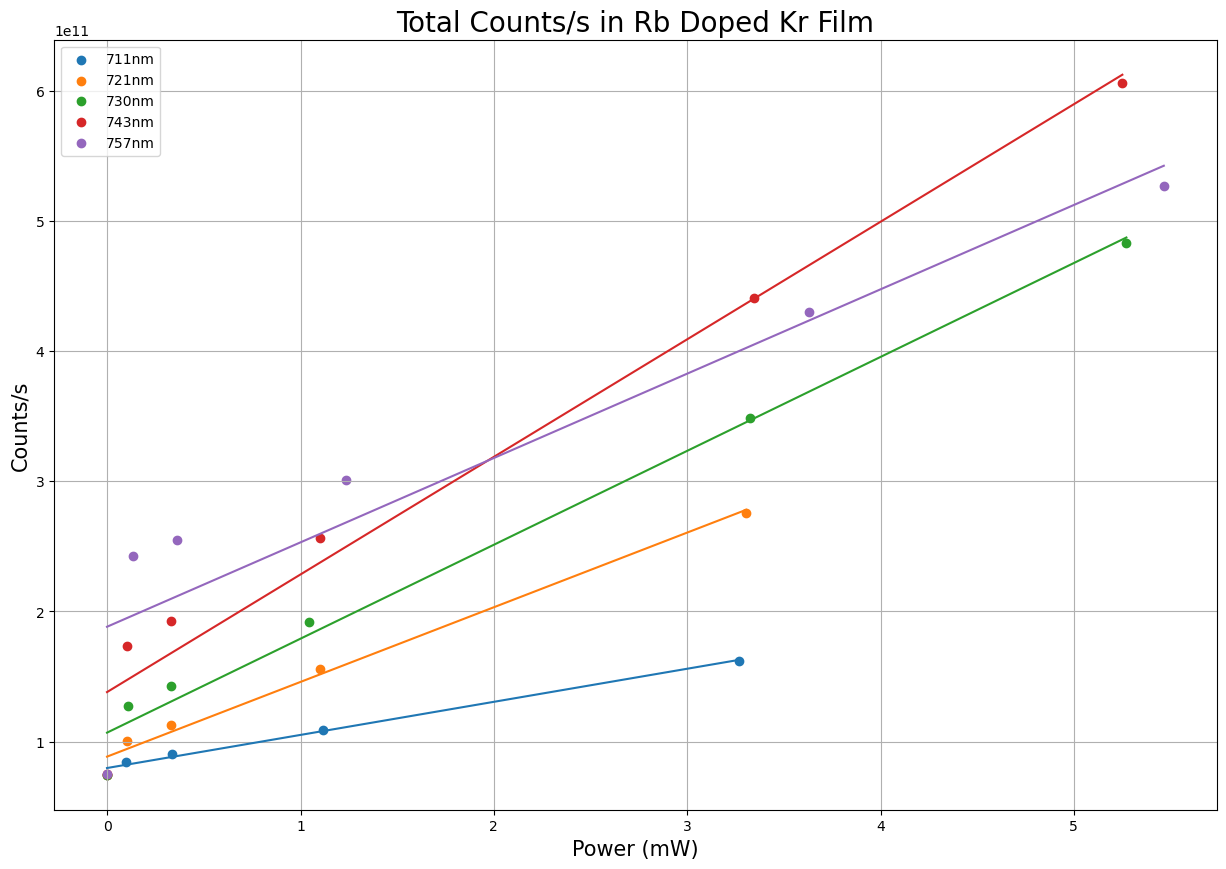

In [28]:
plt.figure(figsize=(15,10))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cpsDoped[i], label=list(doped_nm_dict)[i]+"nm")
plt.legend()
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("Total Counts/s in Rb Doped Kr Film", fontsize=20)

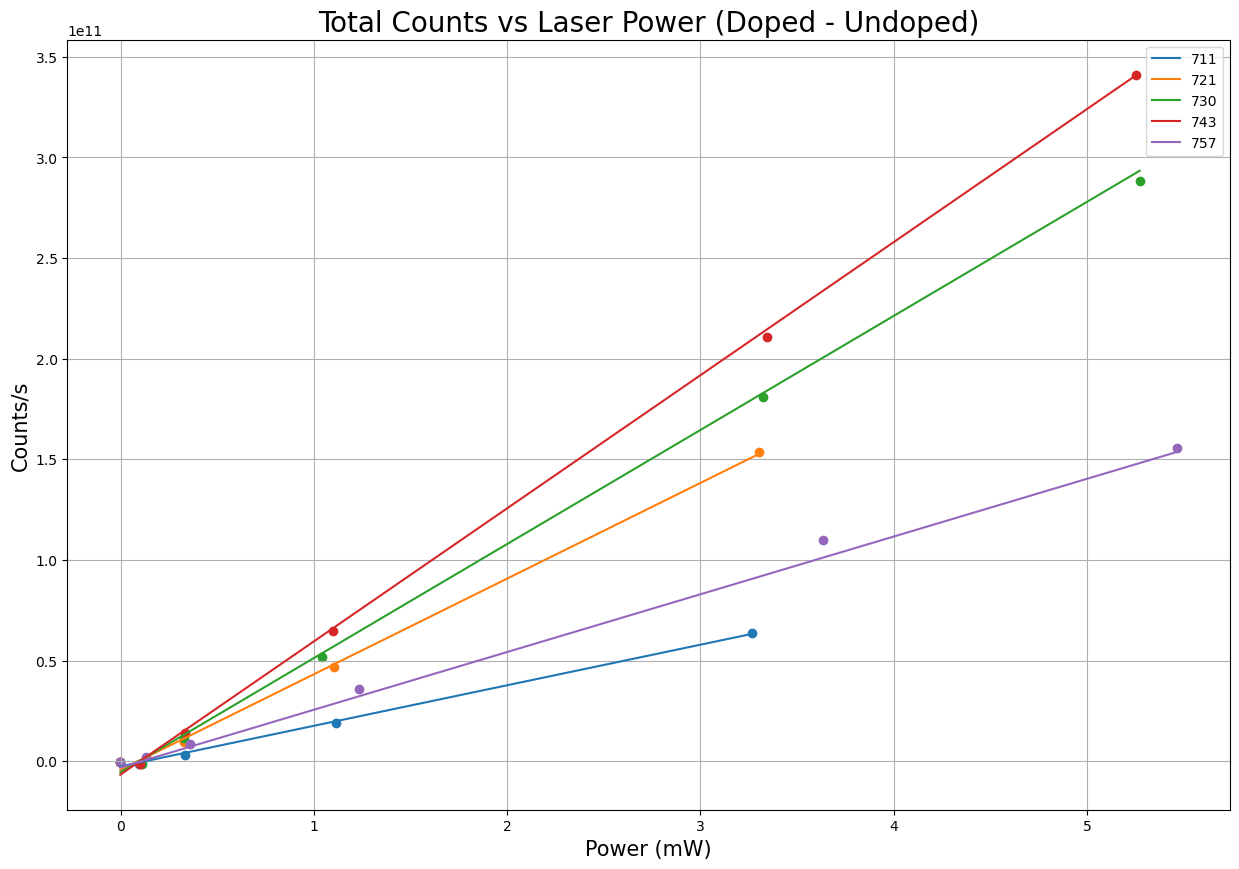

In [29]:
plt.figure(figsize=(15,10))
for i in range(len(cpsDoped)):
    trend = np.polyfit(averagePowerDoped[i], cpsDoped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cpsUndoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_nm_dict)[i])
    plt.scatter(averagePowerDoped[i], np.array(cpsDoped[i]) - np.array(cpsUndoped[i]))
plt.legend()
plt.title("Total Counts vs Laser Power (Doped - Undoped)", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.grid()

In [30]:
%%time
p = r"D:\Karina Data 2.16.26\Empty"
#set up dictionaries
undoped_spe_dict = {}
undoped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    print(wavelength)
    power_dict = {}
    power_settings_dict = {}
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                spo = spe.SpeReference(fp)
                test2 = spe.SpeReference.get_data(spo)[0].astype(np.float32)
                power_dict[power] = test2
            else:
                continue

    undoped_spe_dict[wavelength] = power_dict
    undoped_spe_settings_dict[wavelength] = power_settings_dict

730
743
757
711
721
CPU times: total: 45 s
Wall time: 1min 9s


In [31]:
%%time
p = r"D:\Karina Data 2.16.26\Doped"
#set up dictionaries
doped_spe_dict = {}
doped_spe_settings_dict = {}
#iterate through wavelengths
for wavelength_folder in os.listdir(p):
    wavelength_path = os.path.join(p, wavelength_folder)
    #replace folder name so that it is only the wavelength number
    wavelength = wavelength_folder.replace("LPS ","")
    wavelength = wavelength.replace(" nm", "")
    power_dict = {}
    power_settings_dict = {}
    print(wavelength)
    #iterate through powers
    for power in os.listdir(wavelength_path):
        power_path = os.path.join(wavelength_path, power)
        #replace folder name so that it's only the power
        power = power.replace(" mW","")
        #for each power
        for file in os.listdir(power_path):
            fp = os.path.join(power_path, file)
            if ".spe" in file:  
                spo = spe.SpeReference(fp)
                test2 = spe.SpeReference.get_data(spo)[0].astype(np.float32)
                power_dict[power] = test2
            else:
                continue
    doped_spe_dict[wavelength] = power_dict


721
730
743
757
711
CPU times: total: 40.6 s
Wall time: 1min 4s


In [32]:
print(list(doped_spe_dict.keys()))
print(list(undoped_spe_dict.keys()))

['721', '730', '743', '757', '711']
['730', '743', '757', '711', '721']


In [33]:
#sort by wavelength
undoped_spe_dict = {k: v for k, v in sorted(undoped_spe_dict.items(), key=lambda item: item[0])}
doped_spe_dict = {k: v for k, v in sorted(doped_spe_dict.items(), key=lambda item: item[0])}


In [34]:
print(undoped_settings_nm[0][0].iloc[1,1])

0.01


In [35]:
print(list(undoped_nm_dict.keys()))
print(list(undoped_spe_dict.keys()))

['711', '721', '730', '743', '757']
['711', '721', '730', '743', '757']


In [36]:
#convert to lists
undoped_spe = []
for wavelength in undoped_spe_dict:
    power_dict = undoped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    undoped_spe.append(power_list)
doped_spe = []
for wavelength in doped_spe_dict:
    power_dict = doped_spe_dict[wavelength]
    power_list = [power_dict[p] for p in power_dict]
    doped_spe.append(power_list)

In [37]:
#set region of interest (ROI)
#I'm using Erin's 
roi_x1 = 390
roi_x2 = 700
roi_y1 = 450
roi_y2 = 700
#roi sizes
roi_x = roi_x2 - roi_x1
roi_y = roi_y2 - roi_y1
#also define total area
x_size = 1024
y_size = 1024

In [38]:
#get roi lists
undoped_spe_roi = []
for wavelength in undoped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_spe_roi.append(roi)
doped_spe_roi = []
for wavelength in doped_spe: 
    roi = []
    for power in wavelength:
        roi.append(power[:, roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_spe_roi.append(roi)

In [39]:
print(np.shape(undoped_spe_roi[0][0]))

(103, 251, 311)


In [40]:
#find total counts for whole frame
undoped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe]
doped_total = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe]

In [41]:
#find total counts for roi
undoped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in undoped_spe_roi]
doped_avgs = [[np.mean(np.sum(power, axis=(1,2))) for power in wavelength] for wavelength in doped_spe_roi]

In [42]:
for i in range(len(averagePowerDoped)):
    print(len(averagePowerDoped[i]))
    print(len(averagePowerUndoped[i]))

5
5
5
5
6
6
6
6
6
6


In [43]:
#find counts per second for roi
cps_undoped = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in undoped_avgs]
cps_doped = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in doped_avgs]

In [44]:
#find counts per second for full frame
cps_total_u = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in undoped_total]
cps_total_d = [[power/float(doped_settings_nm[0][0].iloc[1,1])  for power in wavelength] for wavelength in doped_total]

In [45]:
# cps_total_u[1] = cps_total_u[1][:5]

# for i in range(len(cps_total_u)):
#     plt.scatter(averagePowerUndoped[i],cps_total_u[i], color='c')
#     plt.scatter(averagePowerUndoped[i], cpsUndoped[i],color='r')

In [46]:
cps_undoped[1] = cps_undoped[1][:5]
# cps_doped = cps_doped[:5]

In [47]:
for i in range(len(cps_undoped)):
    print(len(cps_total_u[i]))
    print(len(averagePowerUndoped[i]))

5
5
6
5
6
6
6
6
6
6


Text(0.5, 1.0, 'Total counts in undoped Kr film')

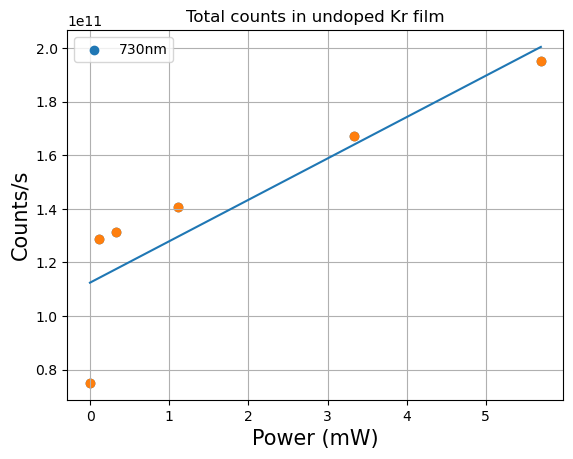

In [48]:
trend = np.polyfit(averagePowerUndoped[2], cps_total_u[2], 1)
plot = np.poly1d(trend)
plt.plot(averagePowerUndoped[2], plot(averagePowerUndoped[2]))
plt.scatter(averagePowerUndoped[2], cps_total_u[2], label=list(undoped_spe_dict)[2]+"nm")
plt.scatter(averagePowerUndoped[2], cpsUndoped[2])
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.legend()
plt.title("Total counts in undoped Kr film")

Text(0.5, 1.0, 'ROI counts in undoped Kr film')

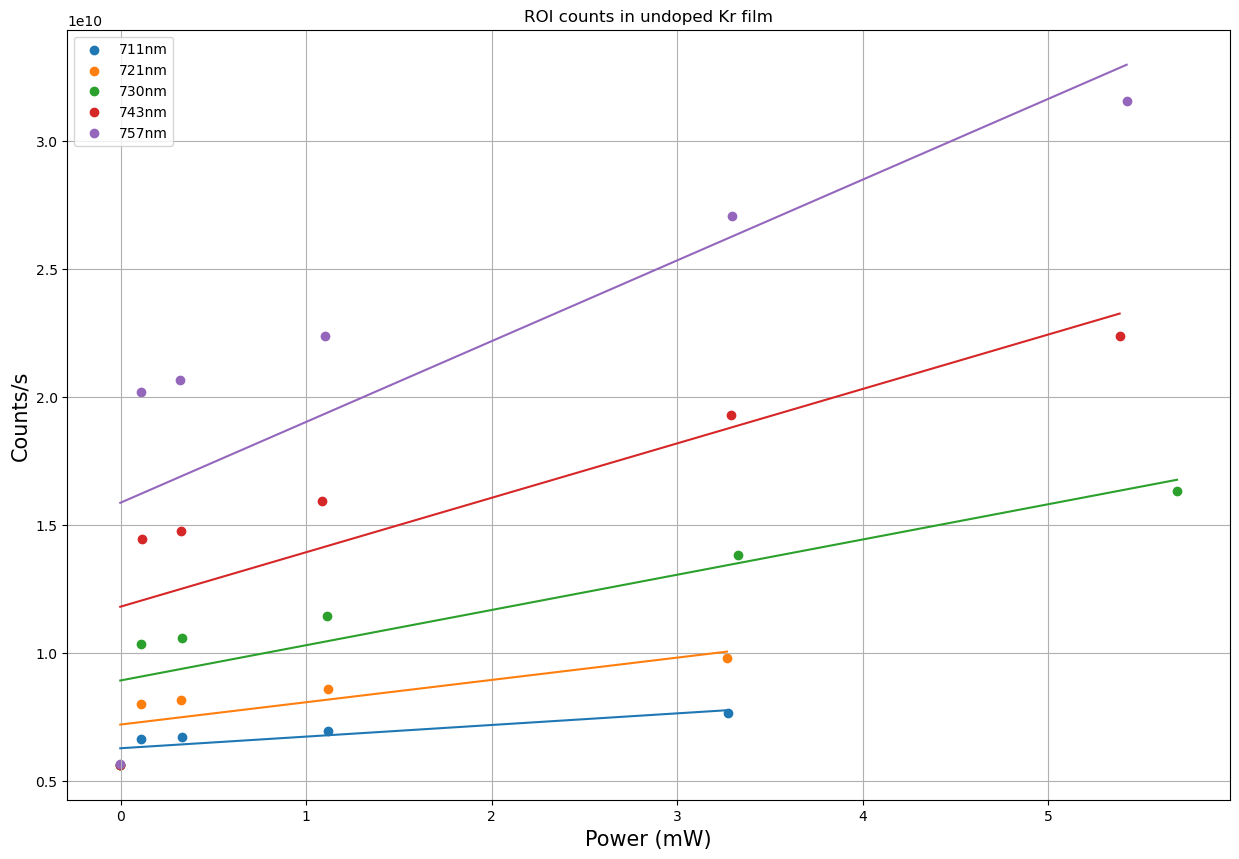

In [49]:
plt.figure(figsize=(15,10))
for i in range(len(cps_undoped)):
    trend = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerUndoped[i], plot(averagePowerUndoped[i]))
    plt.scatter(averagePowerUndoped[i], cps_undoped[i], label=list(undoped_spe_dict)[i]+"nm")
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.legend()
plt.title("ROI counts in undoped Kr film")

Text(0.5, 1.0, 'ROI Counts in Rb Doped Krypton Film')

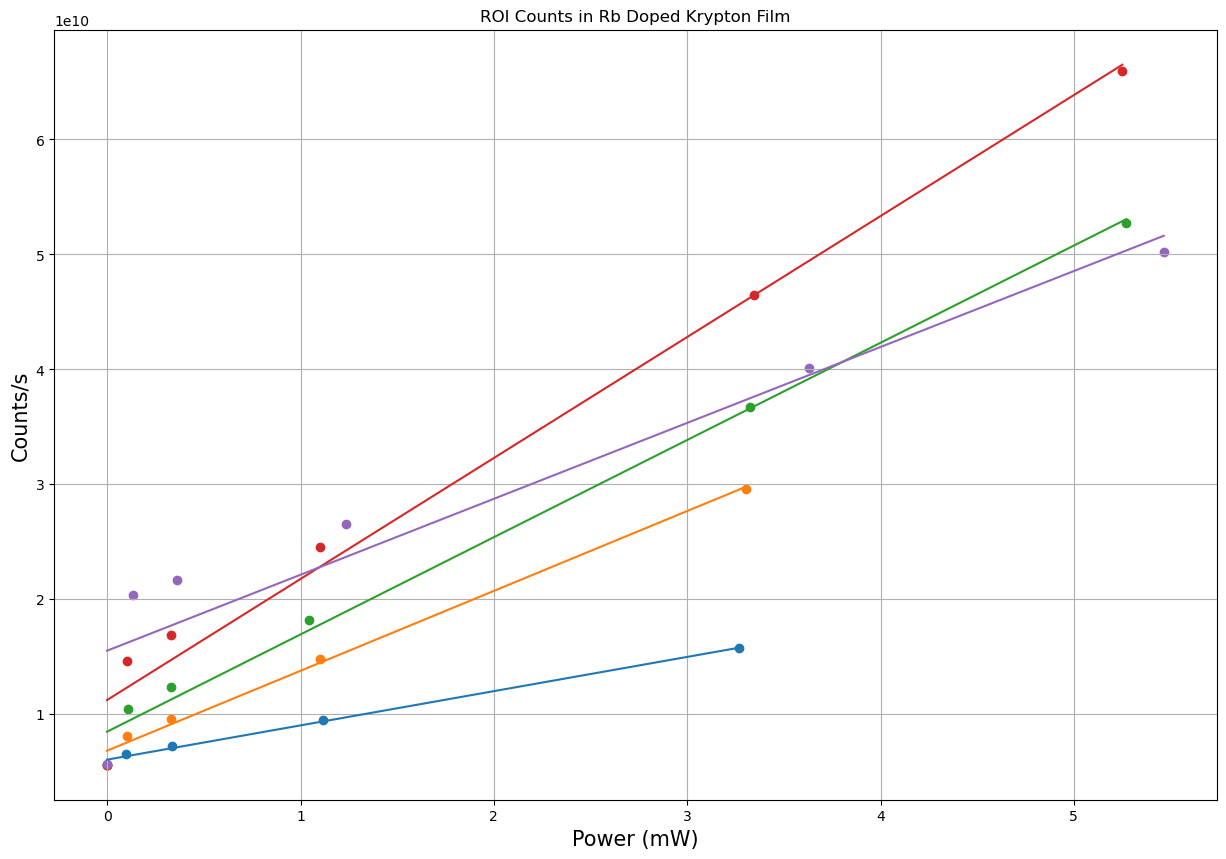

In [50]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    plot = np.poly1d(trend)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]))
    plt.scatter(averagePowerDoped[i], cps_doped[i], label=list(doped_spe_dict)[i]+"nm")
plt.grid()
plt.xlabel("Power (mW)", fontsize=15)
plt.ylabel("Counts/s", fontsize=15)
plt.title("ROI Counts in Rb Doped Krypton Film")

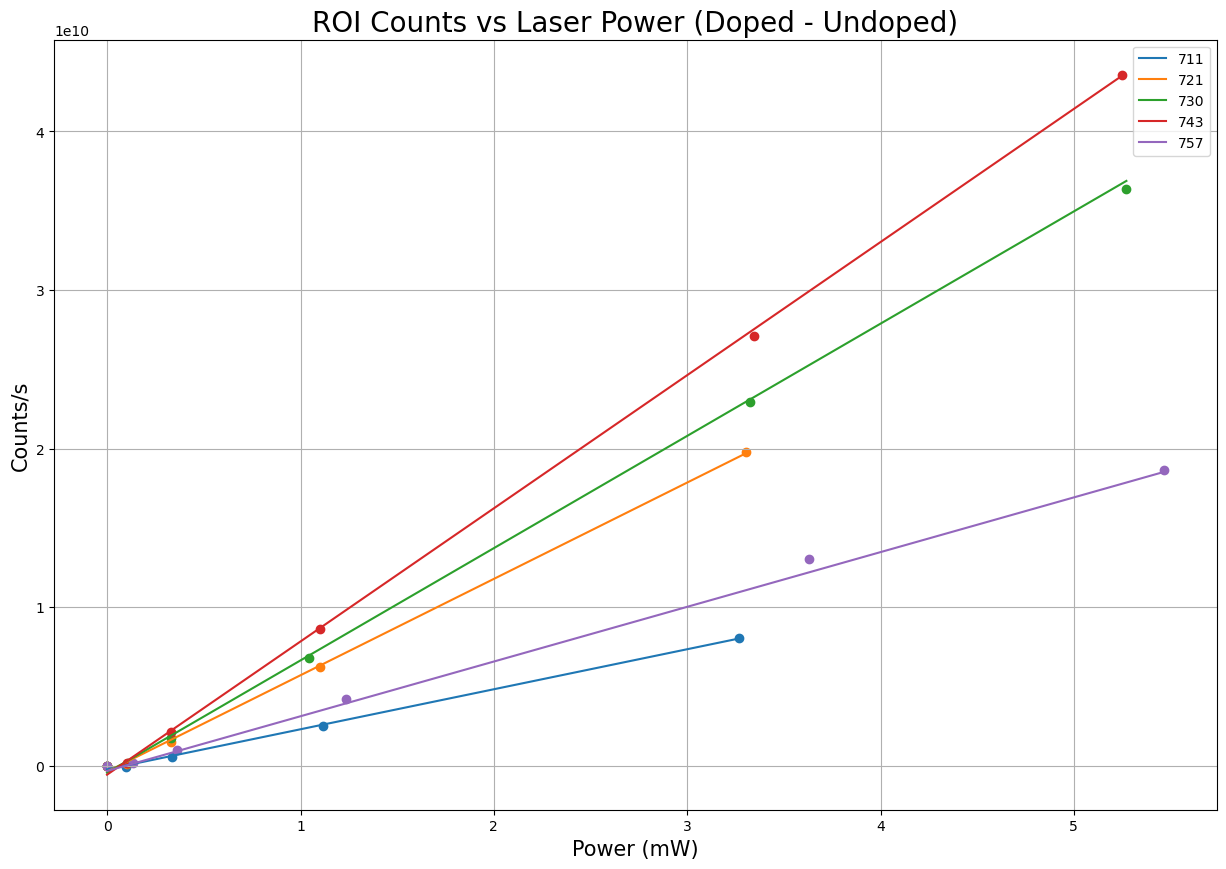

In [51]:
plt.figure(figsize=(15,10))
for i in range(len(cps_doped)):
    trend = np.polyfit(averagePowerDoped[i], cps_doped[i], 1)
    trend1 = np.polyfit(averagePowerUndoped[i], cps_undoped[i], 1)
    diff = trend - trend1
    plot = np.poly1d(diff)
    plt.plot(averagePowerDoped[i], plot(averagePowerDoped[i]), label=list(doped_spe_dict)[i])
    plt.scatter(averagePowerDoped[i], np.array(cps_doped[i]) - np.array(cps_undoped[i]))
plt.legend()
plt.title("ROI Counts vs Laser Power (Doped - Undoped)", fontsize=20)
plt.xlabel("Power (mW)",fontsize=15)
plt.ylabel("Counts/s",fontsize=15)
plt.grid()

In [52]:
#find average counts for each pixel in the ROI
cpp_undoped = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in undoped_spe_roi]
cpp_doped = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in doped_spe_roi]

In [53]:
#define important stuff
substrate_width = 2.54 #cm
pixel_area = (substrate_width / x_size)**2 #cm^2
pixel_width = substrate_width / x_size

In [54]:
#find average counts for each pixel in the full frame
cpp_undoped_tot = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in undoped_spe]
cpp_doped_tot = [[(np.mean(power, axis=(0))/float(doped_settings_nm[0][0].iloc[1,1])) for power in wavelength] for wavelength in doped_spe]

In [55]:
#find intensity (assuming power is evenly distributed)
intensity_undoped = []
for wavelength in averagePowerUndoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_undoped.append(intensity)

intensity_doped = []
for wavelength in averagePowerDoped: 
    intensity = []
    for power in wavelength:
        intensity.append(power / (x_size * y_size * pixel_area))
    intensity_doped.append(intensity)

In [56]:
#cut everything down
#i need a better way to do this but i have not had the time and rn it's the least of my worries
for i in range(len(cpp_undoped)):
    cpp_undoped[i] = np.array(cpp_undoped[i])[:5]
    cpp_doped[i] = np.array(cpp_doped[i])[:5]
    intensity_doped[i] = np.array(intensity_doped[i])[:5]
    cpp_doped[i] = cpp_doped[i][:5]
    intensity_undoped[i] = intensity_undoped[i][:5]
    cpp_doped_tot[i] = cpp_doped_tot[i][:5]
    cpp_undoped_tot[i] = cpp_undoped_tot[i][:5]

    
    

In [57]:
#calculate slopes for each pixel (evenly distributed model)
allrows= []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(intensity_doped[i], cpp_doped[i][:,y,x], 1)
            best1, ignore = np.polyfit(intensity_undoped[i], cpp_undoped[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows.append(rows)

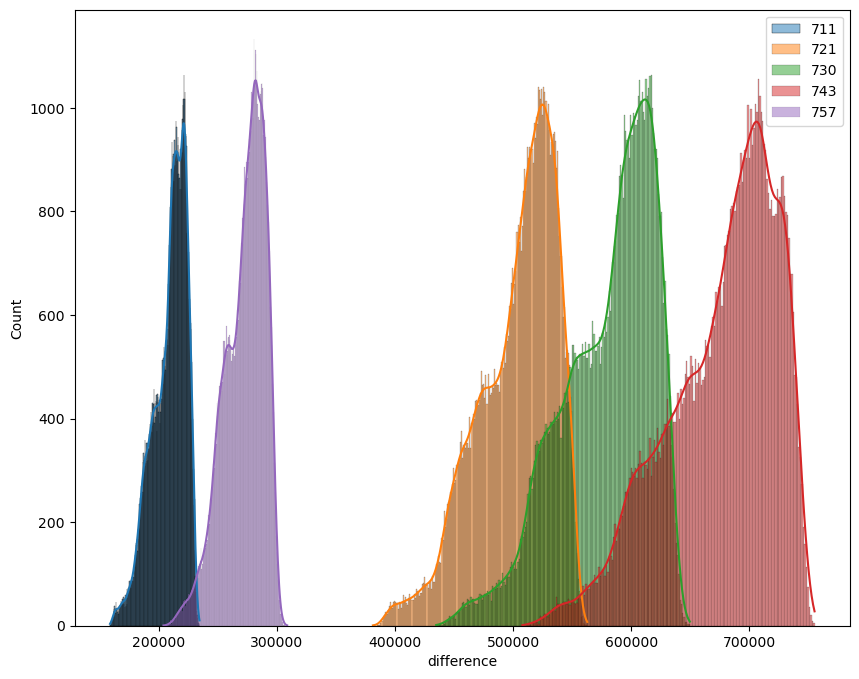

In [58]:
#graph

bins=200
plt.figure(figsize=(10,8))
for i in range(len(allrows)):
    slopes_table = pd.DataFrame(allrows[i])
    sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label=list(undoped_spe_dict)[i])

plt.legend()

In [59]:
print(np.shape(cpp_undoped))

(5, 5, 251, 311)


In [60]:
#find the fraction of counts at each pixel for the undoped frame in the ROI
fractionalCounts = []
for wavelength in cpp_undoped: 
    fraction = []
    for power in wavelength:
        fraction.append(power/ np.sum(power))
    fractionalCounts.append(fraction)

In [61]:
#find the fraction of counts at each pixel for the undoped frame in the full frame

fractionalCountsTotal = []
for wavelength in cpp_undoped_tot: 
    fraction = []
    for power in wavelength:
        fraction.append(power/ np.sum(power))
    fractionalCountsTotal.append(fraction)

In [62]:
for i in range(len(averagePowerUndoped)):
    print(len(averagePowerUndoped[i]))
    print(len(fractionalCountsTotal[i]))

5
5
5
5
6
5
6
5
6
5


In [63]:
#find normalized power
normalized_power_undoped = []
normalized_power_doped = []
for i in range(len(fractionalCountsTotal)):
    norm = []
    norm_doped = []
    for j in range(len(fractionalCountsTotal[i])):
        #multiply the average total power by the percent of power at that pixel to get a per pixel power aka intensity
        norm.append(averagePowerUndoped[i][j] * fractionalCountsTotal[i][j])
        norm_doped.append(averagePowerDoped[i][j] * fractionalCountsTotal[i][j])
    normalized_power_undoped.append(norm)
    normalized_power_doped.append(norm_doped)

In [64]:
#divide by area to get an intensity per cm^2
normalized_power_area_undoped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_undoped]
normalized_power_area_doped = [[power/pixel_area for power in wavelength] for wavelength in normalized_power_doped]

In [65]:
print(cps_total_u)

[[74982073600.0, 86339552000.0, 87213856000.0, 90250483200.0, 98448416000.0], [74994521600.0, 102222400000.0, 103614291200.0, 108681971200.0, 122281868800.0, 137500620800.0], [75045331200.0, 128658944000.0, 131271398400.0, 140658291200.0, 167285580800.0, 195181593600.0], [75069299200.0, 174894822400.0, 178451763200.0, 191810124800.0, 229903872000.0, 265049728000.0], [75200825600.0, 240931097600.0, 246222208000.0, 265659059200.0, 319658956800.0, 371037209600.0]]


In [66]:
print((normalized_power_area_undoped[0][3].mean()))
print(intensity_undoped[0][3])

0.17343499
0.17343501934412195


In [67]:
#change all to arrays
for i in range(len(normalized_power_area_undoped)):
    normalized_power_area_undoped[i] = np.array(normalized_power_area_undoped[i])
    normalized_power_area_doped[i] = np.array(normalized_power_area_doped[i])
print(np.shape(normalized_power_area_undoped[0]))

(5, 1024, 1024)


In [68]:
#cut normalized power down to roi
undoped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    undoped_roi_pwr.append(np.array(roi))
doped_roi_pwr = []
for wavelength in normalized_power_area_undoped: 
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    doped_roi_pwr.append(np.array(roi))
cpp_doped_roi = []
for wavelength in cpp_doped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_doped_roi.append(np.array(roi))
cpp_undoped_roi = []
for wavelength in cpp_undoped_tot:
    roi = []
    for power in wavelength:
        roi.append(power[roi_y1:roi_y2+1, roi_x1:roi_x2+1])
    cpp_undoped_roi.append(np.array(roi))

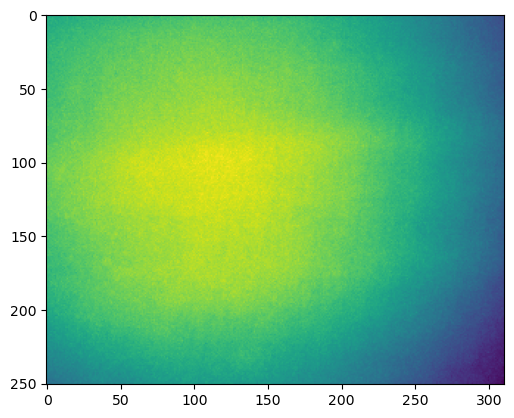

In [69]:
#find new slopes per cm for the normalized power
allrows2 = []
for i in range(len(cpp_undoped)):
    rows = []
    for y in range(roi_y):
        for x in range(roi_x):
            best, ignore = np.polyfit(doped_roi_pwr[i][:,y,x], cpp_doped_roi[i][:,y,x], 1)
            best1, ignore = np.polyfit(undoped_roi_pwr[i][:,y,x], cpp_undoped_roi[i][:,y,x], 1)
            rows.append({'x':x, 'y':y, 'doped slope': best, 'undoped slope': best1, 'difference':best-best1})
    allrows2.append(rows)

average ROI slope of 711 nm: 198984.73849879528
STDEV difference between models for 711 nm: 1556.5418396615332
average ROI slope of 721 nm: 471227.21300318406
STDEV difference between models for 721 nm: 5146.553976209099
average ROI slope of 730 nm: 520106.2298627668
STDEV difference between models for 730 nm: 8231.472722630911
average ROI slope of 743 nm: 613860.9792716713
STDEV difference between models for 743 nm: 10118.024090233492
average ROI slope of 757 nm: 291710.7202174536
STDEV difference between models for 757 nm: 2921.5564607314354


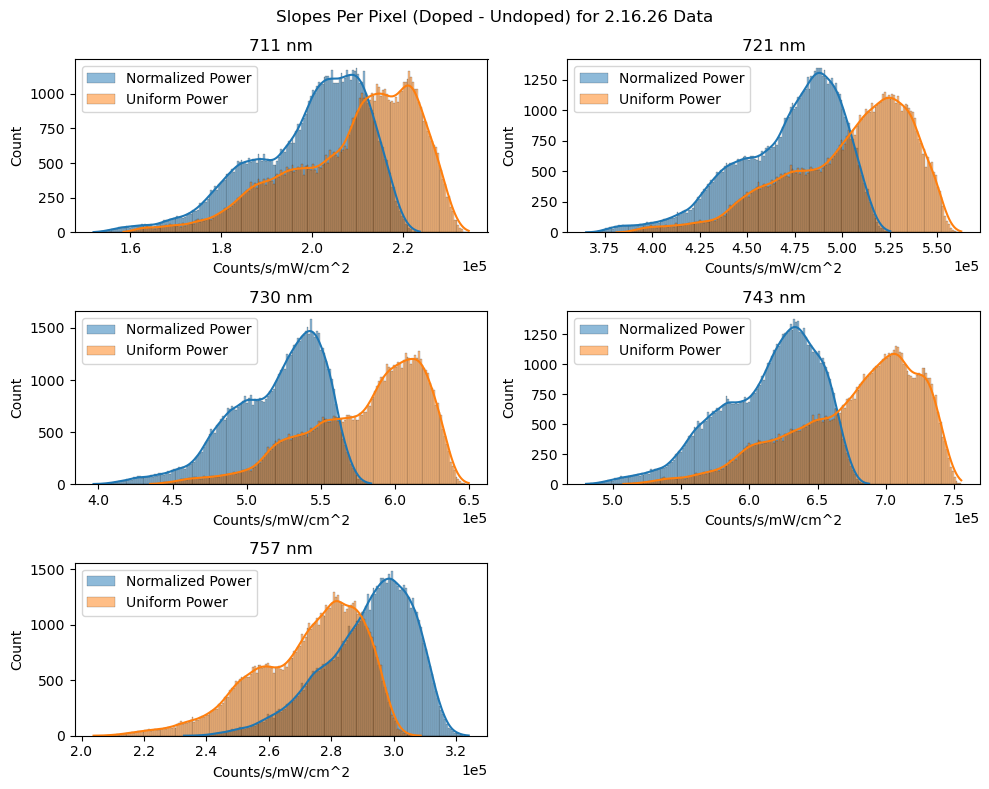

In [70]:
normalized_slopes = []
#graph comparisons
plt.figure(figsize=(10,8))
plt.suptitle("Slopes Per Pixel (Doped - Undoped) for 2.16.26 Data")
for i in range(len(allrows2)):
    x = int(i)
    plt.subplot(3,2, i+1)
    slopes_table2 = pd.DataFrame(allrows2[i])
    normalized_slopes.append(slopes_table2)
    slopes_table = pd.DataFrame(allrows[i])
    histogram = np.concatenate([slopes_table["difference"], slopes_table2["difference"]])
    bins = np.linspace(histogram.min(), histogram.max(), 200)
    sns.histplot(slopes_table2["difference"], kde=True, bins=bins,  label="Normalized Power")
    sns.histplot(slopes_table["difference"], kde=True, bins=bins,  label="Uniform Power")
    plt.title(list(undoped_spe_dict)[i]+" nm")
    plt.ticklabel_format(axis='x', style='sci', scilimits=(5,5))
    plt.xlabel("Counts/s/mW/cm^2")
    print("average ROI slope of", list(undoped_nm_dict)[i], "nm:", slopes_table2["difference"].mean())
    print("STDEV difference between models for", list(undoped_nm_dict)[i], "nm:", slopes_table["difference"].std() - slopes_table2['difference'].std())


    plt.legend()
plt.tight_layout()

## everything past here does not work rn 

In [72]:
r = 2.54/2
z_film = 98.45 #cm
#given x and given y we can find hypotenuse which is r for each pixel (for distance from center of film)
film_size_x = np.linspace(0,1024,1024)
film_size_y = np.linspace(0,1024,1024)
film_size = np.zeros((1024,1024,2))
dist = np.zeros((1024, 1024, 2))

In [73]:
%%time

for x in range(len(film_size_x)):
    for y in range(len(film_size_y)):
        dist[x,y] = 511 - x , 511 - y

#dist = dist  * np.sqrt(pixel_area)

CPU times: total: 1.09 s
Wall time: 1.09 s


In [74]:
%%time
def distance(x):
    return (511 - x)

dist2 = [list(map(distance, row)) for row in film_size]

CPU times: total: 5.48 s
Wall time: 5.52 s


In [75]:
#distance from center of lens
z_lens = 41.8 #cm
r_lens = 2.54
bin_size = (r_lens/4)
lens_size_x = np.linspace(-512,512,1024)
lens_size_y = np.linspace(-512,512, 1024)
lens_dist = np.zeros((1024,1024,2))

for x in range(len(lens_size_x)):
    for y in range(len(lens_size_y)):
        lens_dist[x,y] = 511 - x , 511 - y

#lens_dist = lens_dist * bin_size

In [76]:
# print((lens_dist_x))
# lensgrid = np.zeros((4,4))
# sa = np.zeros((1024,1024))
# #print(lensgrid)

In [77]:
#sa constants
r_lens = 5.08/2
lens_area = np.pi*(r_lens**2)
z_lens = 41.78
sphere = 4*np.pi*(z_lens**2)
sa_whole = lens_area / sphere

In [78]:
# output is array with dimensions (Npts*Npts,3)
# where first index is the point number which is composed of a 3D location vector
# origin is the top of curved surface and if Rc>0, then the rest of the points are below the xy-plane
# the normal vector for the tip of the spherical cap is z-hat
def get_surface_spherical_cap_3D(Npts,Rc,dia):
    nvecs = np.zeros((Npts*Npts,3))
    locs = np.zeros((Npts*Npts,3))
    lets_try =[]
    lets_try_2 = []
    R = dia/2.0
    z = np.sqrt(Rc**2-R**2)
    count = 0
    for k in np.arange(Npts):
        rk = R*(3.0*k*k+3.0*k+1.0)/3.0/Npts/np.pi
        randphi = np.random.uniform(0.0,2.0*np.pi)
        for l in np.arange(2*k+1):
            
            phil = 2.0*np.pi*l/(2.0*k+1.0)+randphi
            xkl = +rk*(np.sin(phil+2.0*np.pi/(2.0*k+1.0))-np.sin(phil))
            ykl = -rk*(np.cos(phil+2.0*np.pi/(2.0*k+1.0))-np.cos(phil))
            phi = np.arctan2(ykl,xkl)
            theta = np.arctan(np.sqrt(xkl**2+ykl**2)/z)
            nvecs[count] = np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
            locs[count] = np.array([Rc*np.sin(theta)*np.cos(phi),Rc*np.sin(theta)*np.sin(phi),Rc*np.cos(theta)-Rc])
            if len(lets_try) > Npts: 
                continue
            else:
                lets_try.append(nvecs[count])
                lets_try_2.append(locs[count])
            count = count+1
    return locs , nvecs, lets_try, lets_try_2

In [79]:
blah = np.zeros((1024,1024,3))
print(blah[1023][0])

[0. 0. 0.]


In [80]:
pieces = 4

pixels = 1024
pixel_width = 2.54 / pixels
bin_size = 5.08/pieces
lens = np.zeros((pieces, pieces))
r_film = 2.54/2 


In [81]:
%%time
lens_loc, normal, one_loc, one_normal = get_surface_spherical_cap_3D(pixels, z_lens, r_lens*2)

CPU times: total: 1min 10s
Wall time: 1min 12s


In [82]:
def bin_size(ring_number):
    inner_ring = np.pi * (ring_number)**2 * pixel_width**2
    outer_ring = np.pi * (ring_number+1)**2 * pixel_width**2
    area = outer_ring - inner_ring
    return area

In [83]:
one_loc = np.array(one_loc)
one_normal = np.array(one_normal)

In [ ]:
# sa = np.zeros((pixels, pixels)) 
# for x in range(len(sa[0])):
#     for y in range(len(sa[1])):
#         x_dist = (x - (.5*pixels)) * pixel_width 
#         y_dist = (y - (.5*pixels)) * pixel_width 
#         if x_dist**2 + y_dist**2 > r**2: sa[x,y] = 0 
#             continue 
#     else: 
#         for a in range(len(lens[0])): 
#             for b in range(len(lens[1])): 
#                 lx_dist = (a + 0.5 - 0.5*pieces) * bin_size 
#                 ly_dist = (b + 0.5 - 0.5*pieces) * bin_size 
#                 displacement = np.sqrt((lx_dist - x_dist)**2 + (ly_dist - y_dist)**2) 
#                 hyp = np.sqrt(z_lens**2 + displacement**2) 
#                 if lx_dist**2 + ly_dist**2 > r_lens**2: 
#                     sa[x,y] += 0 
#                     continue
#                     denom = 4*np.pi*((hyp**3)) 
#                     sa[x,y] += (z_lens*bin_size*bin_size/denom)

In [85]:
binn = []
for i,val in enumerate(one_loc):
    binn.append(bin_size(i))

In [87]:
binn = np.array(binn)
print(binn)

[1.93293563e-05 5.79880690e-05 9.66467817e-05 ... 3.95285337e-02
 3.95671924e-02 3.96058512e-02]


In [89]:
%%time
@numba.njit(parallel=True)
def safactor(pieces):
    sa = np.zeros((pixels, pixels))
    lens = np.zeros((pieces, pieces))
    for x in numba.prange(len(sa[0])):
        for y in numba.prange(len(sa[1])):
    
            x_dist = (x - (.5*pixels)) * pixel_width
            y_dist = (y - (.5*pixels)) * pixel_width
            if x_dist**2 + y_dist**2 > r_film**2:
                sa[x,y] = 0
                continue
            else:
                for i in range(len(one_loc)):
                    lx, ly, lz = one_loc[i]
                    nx, ny, nz = one_loc[i]
                    bin_size = binn[i]
                    lx_dist = lx
                    ly_dist = ly
                    xx = x_dist - lx_dist
                    yy = y_dist - ly_dist
                    zz = z_lens - lz 
                    displacement = np.sqrt((-lx_dist + x_dist)**2 + (-ly_dist + y_dist)**2) 
                    hyp = np.sqrt(xx**2 + yy**2 + zz**2)
                    if lx_dist**2 + ly_dist**2 > r_lens**2:
                        sa[x,y] += 0
                        continue
                    numerator = ( xx*nx + yy*ny + zz*nz)
                    denom = 4*np.pi*((hyp**3))
                    sa[x,y] += (numerator*bin_size/denom)
    return sa

CPU times: total: 31.2 ms
Wall time: 57.2 ms


In [91]:
%%time
sa = safactor(1024)

CPU times: total: 16.8 s
Wall time: 6.56 s


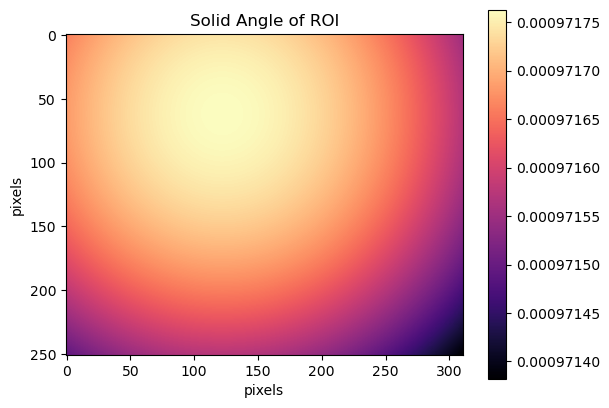

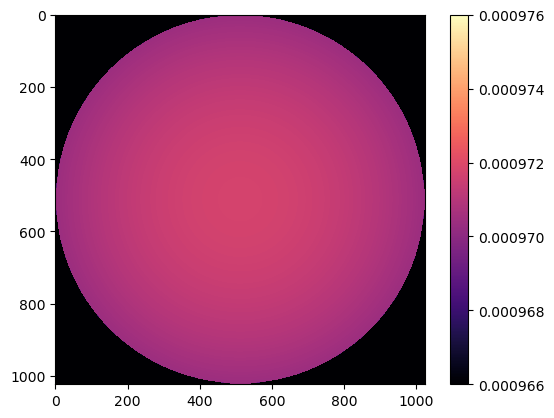

In [94]:

sa_roi = sa[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]

plt.imshow(sa_roi, 'magma')
plt.colorbar()
plt.title('Solid Angle of ROI')
plt.xlabel('pixels')
plt.ylabel('pixels')
plt.show()
plt.imshow(sa,'magma')
plt.colorbar()
plt.clim(0.000966, 0.000976)

In [96]:
sa_df = []
for y in range(len(sa_roi)):          # number of rows
    for x in range(len(sa_roi[0])):   # number of columns
        sa_df.append({
            'x': x,
            'y': y,
            'value': sa_roi[y][x]})

In [98]:
sa_df = pd.DataFrame(sa_df)

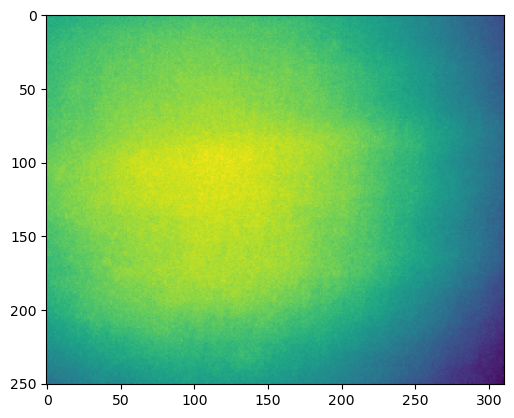

In [683]:
plt.imshow(cpp_doped[1][3]/sa_roi/atoms_roi)

In [100]:
sa_df.head()

,x,y,value
0,0,0,0.000972
1,1,0,0.000972
2,2,0,0.000972
3,3,0,0.000972
4,4,0,0.000972


In [102]:
slopes_table2['sa'] = slopes_table2['difference'] / sa_df['value']

In [104]:
slopes_table2['sa_whole'] = slopes_table2['difference'] / sa_whole

In [106]:
print(np.mean(sa_df['value']))
print(sa_whole)

0.0009716636661221554
0.0009239970201110421


-768020.1362705175


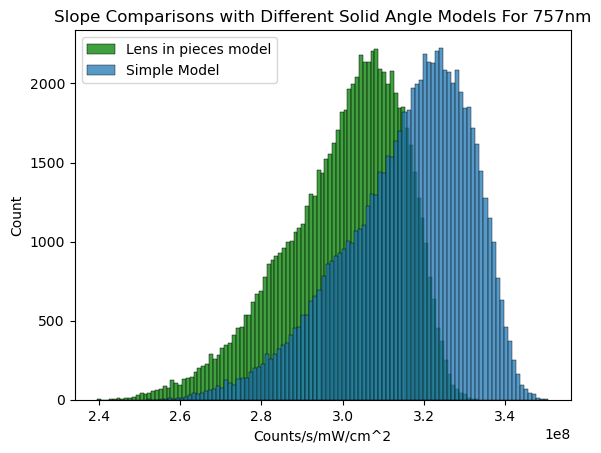

In [108]:
# histogram = np.concatenate([slopes_table2["sa_whole"], slopes_table2['sa']])
# bins = np.linspace(histogram.min(), histogram.max(), 200)
sns.histplot(slopes_table2['sa'],color='green',label='Lens in pieces model')#,bins=bins)
sns.histplot(slopes_table2['sa_whole'], label='Simple Model')#,bins=bins)
plt.title("Slope Comparisons with Different Solid Angle Models For 757nm")
plt.xlabel('Counts/s/mW/cm^2')
plt.legend()
print(np.std(slopes_table2['sa']) - np.std(slopes_table2['sa_whole']))

## atomic distribution (it's so big and ugly)

In [111]:
print(growth_rate)

NameError: name 'growth_rate' is not defined

In [581]:
microns_hr = 5
microns_sec = microns_hr / 60 / 60 
cms_sec = microns_sec * 10e-5
growth_rate = cms_sec
flow_rate = 10e9
k = 2.869E-4
gamma = 1/83

In [583]:
from scipy import integrate
import scipy.special as ss
import sympy as sp
from math import erf

In [285]:
def erf(x):
    return ss.erf(x)

In [287]:
def S(z, p):
    inside = (np.sqrt(1-z**2)) * erf(delta_prime(1+(z/p)*((z1/z0)-1))) - erf(delta_prime)
    integral = integrate(inside, z, 0, 2*np.pi)
    return(integral)

In [289]:
num = 1 - 2*(gamma**3) + (2*(gamma**2) - 1)*np.sqrt(1+(gamma**2))
den = np.sqrt(1+(gamma**2)) - (gamma**2)*np.arcsinh(1/gamma)
z0 = 0.5 - (1/(3*(gamma**2))) * (num/den)
z1 = 1 - z0
delta = z0/np.sqrt(2*k*(z1 - z0))
ee = (z1 / z0) * delta


In [291]:
#can we integrate outside our fucntion so that we can use numba? 

sx = lambda x: (np.sqrt(1-(x**2))) * erf(delta_prime*(1+(x/p)*((z1/z0)-1))) - erf(delta_prime)

In [293]:
def sx(x, delta_prime, p, z1, z0):
        return (np.sqrt(1-(x**2))) * erf(delta_prime*(1+(x/p)*((z1/z0)-1))) - erf(delta_prime)

In [295]:
def test_integral(func, a, b, n):
    h = (b - a)/n
    total = 0 
    for i in range(n):
        mid = a + (i + .5) * h
        total += sx(mid, delta_prime, p, z1, z0)
    return total * h

In [297]:
n = 200
h = (p - 0)/n
total = 0 
for i in range(n):
    mid = 0 + (i + .5) * h
    total += (np.sqrt(1-(mid**2))) * (erf(delta_prime*(1+(mid/p)*((z1/z0)-1))) - erf(delta_prime))

TypeError: unsupported operand type(s) for -: 'str' and 'int'

In [315]:
@numba.njit
def tand(theta):
    return np.sin(theta)/np.cos(theta)

In [585]:

def erf(x):
    return math.erf(x)
k = 2.869e-4
g = 1/83
z0 = 0.5 - (1/(3*(g**2)))*((1-2*(g**3)+(2*(g**2)-1)*np.sqrt(1+(g**2)))/(np.sqrt(1+(g**2))-(g**2)*np.arcsinh(1/g)))
z1 = 1 - z0
d = np.sqrt((z0**2)/(2*k*(z1-z0)))    
E = (z1/z0)*d
j_norm = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(erf(E)-erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
@numba.njit
def jang_test2(theta):
    theta = np.deg2rad(theta)
    dp = np.sqrt((d**2)/np.cos(theta))
    zp = (z1/z0)*dp
    F = (2/np.sqrt(np.pi))*zp*((1/z1)-1)*(np.e**(-(zp**2)))
    p = np.tan(theta)/g       
    if theta==0:
        j0 = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(math.erf(E)-math.erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
        j = j0/j_norm
    elif g >= np.tan((theta)): 
        R = np.arccos(p) - p*(np.sqrt(1-(p**2)))
        n = 200
        h = (p - 0)/n
        total = 0 
        for i in range(n):
            mid = 0 + (i + .5) * h
            total += np.sqrt(1-(mid**2))*(math.erf(dp*(1+((g*mid)/np.tan(theta))*((z1/z0)-1))) - math.erf(dp)) 
        j1 = z0*np.cos(theta)*(1+(2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*((R/2)*(math.erf(zp)-math.erf(dp)+F) + (total*h)) ) 
        j = j1/j_norm
    else:
        n = 200
        h = (1 - 0)/n
        total = 0 
        for i in range(n):
            mid = 0 + (i + .5) * h
            total += np.sqrt(1-(mid**2))*(math.erf(dp*(1+((g*mid)/np.tan(theta))*((z1/z0)-1))) - math.erf(dp)) 
        j2 = z0*np.cos(theta)*(1 + (2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*total*h) 
        j = j2/j_norm
    return j

In [587]:

def erf(x):
    return ss.erf(x)
k = 2.869e-4
g = 1/83
z0 = 0.5 - (1/(3*(g**2)))*((1-2*(g**3)+(2*(g**2)-1)*np.sqrt(1+(g**2)))/(np.sqrt(1+(g**2))-(g**2)*np.arcsinh(1/g)))
z1 = 1 - z0
d = np.sqrt((z0**2)/(2*k*(z1-z0)))    
E = (z1/z0)*d
j_norm = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(erf(E)-erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
def jang2(theta):
    k = 2.869e-4
    g = 1/83
    z0 = 0.5 - (1/(3*(g**2)))*((1-2*(g**3)+(2*(g**2)-1)*np.sqrt(1+(g**2)))/(np.sqrt(1+(g**2))-(g**2)*np.arcsinh(1/g)))
    z1 = 1 - z0
    d = np.sqrt((z0**2)/(2*k*(z1-z0)))    
    E = (z1/z0)*d
    j_norm = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(erf(E)-erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
    theta = np.deg2rad(theta)
    dp = np.sqrt((d**2)/np.cos(theta))
    zp = (z1/z0)*dp
    F = (2/np.sqrt(np.pi))*zp*((1/z1)-1)*(np.e**(-(zp**2)))
    p = np.tan(theta)/g       
    sx = lambda x: np.sqrt(1-(x**2))*(erf(dp*(1+((g*x)/np.tan(theta))*((z1/z0)-1))) - erf(dp)) 
    if theta==0:
        j0 = z0 + (np.sqrt(np.pi)/2)*z0*((np.e**(d**2))/d)*(erf(E)-erf(d)) + (1-z1)*(np.e**(-((E**2)-(d**2))))
        j = j0/j_norm
    elif g >= np.tan((theta)): 
        R = np.arccos(p) - p*(np.sqrt(1-(p**2)))
        S1 = integrate.quad(sx, 0, p, epsrel=1e-4)
        j1 = z0*np.cos(theta)*(1+(2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*((R/2)*(erf(zp)-erf(dp)+F) + S1[0]))  
        j = j1/j_norm
    else:
        S2 = integrate.quad(sx, 0, 1)
        j2 = z0*np.cos(theta)*(1 + (2/(np.sqrt(np.pi)))*((np.e**(dp**2))/dp)*S2[0]) 
        j = j2/j_norm
    return j

In [589]:
for t in [0, 0.1, 0.5, .6,.7,1, 2]:
    print(t, jang_test2(t))
    print(t, jang2(t))

0 1.0
0 1.0
0.1 0.9986388423040649
0.1 0.9986305299910595
0.5 0.9931517348707987
0.5 0.9931097013783605
0.6 0.9917699469359547
0.6 0.9917189192881913
0.7 0.9904062860207119
0.7 0.9903239722171532
1 0.9861797655760692
1 0.9861144667969409
2 0.9718709781721396
2 0.9718255010625869


In [591]:
%%time
jang_test2(1)

CPU times: total: 0 ns
Wall time: 0 ns


0.9861797655760692

In [593]:
%%time
#@numba.njit(parallel=True)
# def atoms_in_pixel(theta):
atoms = np.zeros((1024,1024))
for x in range(len(atoms[0])):
    for y in range(len(atoms[1])): 
        
        x_dist = (x - (.5*pixels)) * pixel_width
        y_dist = (y - (.5*pixels)) * pixel_width
        r = np.sqrt(x_dist**2 + y_dist**2)
        theta = (np.rad2deg(np.arctan(r/z_film)) )
        atomic_dist = (flow_rate / growth_rate) * jang_test2(theta)* pixel_width**2 / ( ( z_film**2) * np.pi * k)
        atoms[x,y] = atomic_dist
        if r > r_film:
            atoms[x,y] = 0
            continue
        if r == 0:
            print("OKKK")

OKKK
CPU times: total: 42.8 s
Wall time: 47.7 s


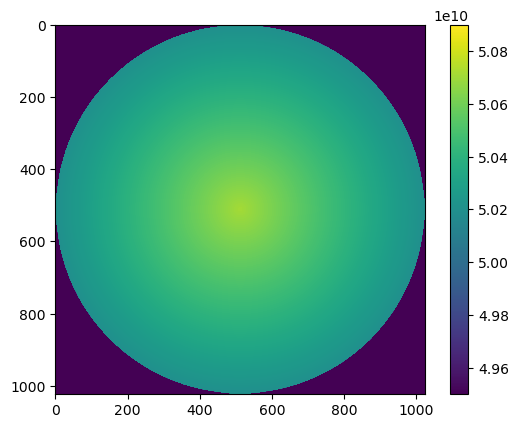

In [643]:

plt.imshow(atoms)
plt.colorbar()
plt.clim(4.95e10, 5.09e10)

In [607]:
atoms_roi = atoms[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1]

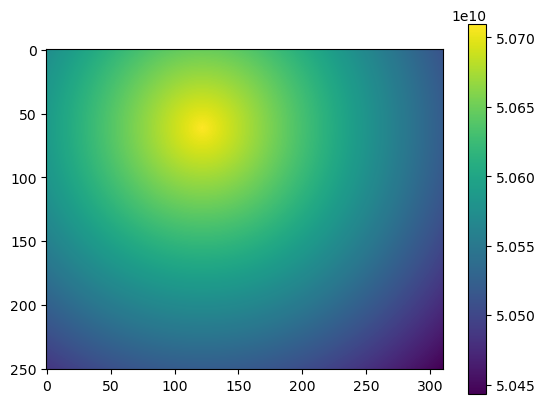

In [623]:
plt.imshow(atoms_roi)
plt.colorbar()

In [609]:
atom_df = []
for y in range(len(atoms_roi)):          # number of rows
    for x in range(len(atoms_roi[0])):   # number of columns
        atom_df.append({
            'x': x,
            'y': y,
            'value': atoms_roi[y][x]})

In [625]:
atom_df = pd.DataFrame(atom_df)
print(atom_df.head())
atom_df.iloc[1, 2]
atom_df.std()

   x  y         value
0  0  0  5.057279e+10
1  1  0  5.057369e+10
2  2  0  5.057458e+10
3  3  0  5.057546e+10
4  4  0  5.057635e+10


x        8.977808e+01
y        7.245735e+01
value    5.450177e+07
dtype: float64

In [ ]:
plt.imshow(

<Axes: xlabel='value', ylabel='Count'>

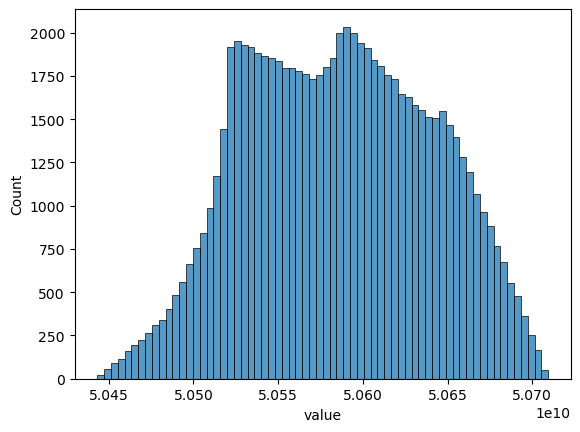

In [627]:
sns.histplot(atom_df['value'])

In [673]:
slopes_table2['atom_dist'] = slopes_table2['sa'] / atom_df['value']

In [674]:
print(slopes_table2['atom_dist'])

0        0.005863
1        0.005797
2        0.005883
3        0.005736
4        0.005734
           ...   
77495    0.004928
77496    0.004965
77497    0.004968
77498    0.004961
77499    0.004905
Name: atom_dist, Length: 77500, dtype: float64


1.0086330252386473


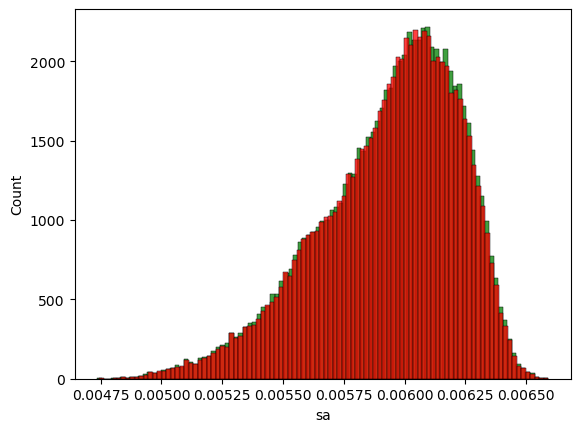

In [677]:
sns.histplot(slopes_table2['sa']/(atom_df['value'].mean()),color='green',label='Lens in pieces model')#,bins=bins)
sns.histplot(slopes_table2['atom_dist'],color='red',label='Lens in pieces model')#,bins=bins)
print((slopes_table2['sa']/atom_df['value'].mean()).std() / slopes_table2['atom_dist'].std())

In [803]:
doped_nm[4][5]


,Loop Start Time (s),Frequency (THz),Power (V),CCD Frame Start Time (s),CCD Total Counts
0,29.463014,396.026997,0.788323,29.495567,6.783198e+08
1,33.201665,396.026998,0.744187,33.233184,5.331169e+09
2,34.344934,396.026997,0.720842,34.375194,5.261032e+09
3,35.495088,396.026995,0.712207,35.526175,5.197375e+09
4,36.655059,396.026996,0.724283,36.685840,5.191102e+09
...,...,...,...,...,...
98,145.212255,396.026995,0.778084,145.243970,5.342665e+09
99,146.365199,396.026996,0.803196,146.396407,5.439398e+09
100,147.521352,396.026990,0.781787,147.552786,5.458306e+09
101,148.674475,396.026993,0.736945,148.707017,5.326666e+09


In [763]:
np.shape(cpp_doped_tot)

(5, 5, 1024, 1024)

In [805]:
ctp = 5.2  # photons/count ratio
transm = 0.9073754  # transmission ratio through lens and filter
texp = 0.8 # CCD exposure time in seconds
pixel_number = 1024
film_pixel_width = 25.4/1000/pixel_number  # film is 1" diameter, so 25.4mm converted to m divided by the number of pixels on the CCD
exp_power = .77/1000  # experimental laser power at time frame was taken, converted to W

wl = 757.0E-9  # laser wavelength in meters

h = 6.62607015E-34 # J*s = W*s^2
vy = 3*10e8/wl # Hz

#N_photons_persec = (((ccd730array - bias)/texp)) * ctp / transm

fcs_array = ( cpp_doped_tot[4][4] * h * vy ) / ( exp_power * atoms * sa )
#fcs_array_cm2 = fcs_array*(100*100)

C:\Users\summe\AppData\Local\Temp\ipykernel_10420\251970899.py:15: RuntimeWarning: divide by zero encountered in divide
  fcs_array = ( cpp_doped_tot[4][4] * h * vy ) / ( exp_power * atoms * sa )


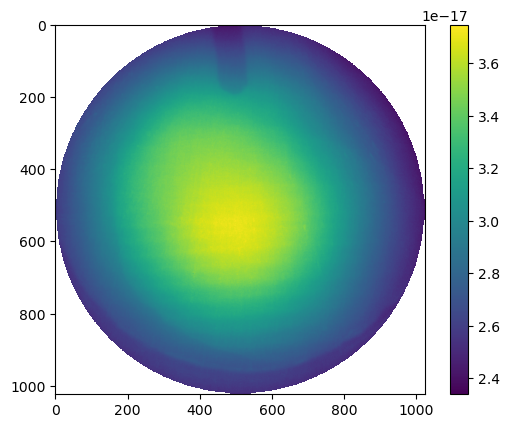

In [807]:
plt.imshow(fcs_array)#[roi_y1:roi_y2 + 1, roi_x1:roi_x2 + 1])
plt.colorbar()